In [1]:
import os
import sys
import json
from textwrap import wrap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sys.path.append(
    os.path.abspath(os.path.join(os.getcwd(), "../.."))
)  # Add parent directory to path

import json
import pandas as pd
import transformers
from datasets import load_dataset

from utils.helpers import parse_output

from utils.constants import DEFAULT_AUGMENT_RESULT

from utils.prompts import (
    JUDGE_SYSTEM_PROMPT,
    JUDGE_TEMPLATE,
    AUGMENT_SYSTEM_PROMPT,
    AUGMENT_TEMPLATE,
)

def wrap_text(text, num_chars):
    return '\n'.join(wrap(text, num_chars))

In [2]:
# Load data
datapath = r"../../../outputs/results/batch_16547013_result.csv"
augmented_data = pd.read_csv(datapath, sep=";")
eval_cols = [11, 12]

# Remove erroneous examples
mask_no_errors = (augmented_data.iloc[:, -2:] != "PARSE ERROR").all(axis=1)

# Keep rows where evaluation columns are all "yes"
mask_all_yes = augmented_data.iloc[:, eval_cols].eq("yes").all(axis=1)

augmented_data = augmented_data[mask_no_errors & mask_all_yes].reset_index()

In [3]:
flag = not True
if flag:
    first_occurrence_by_concept = [augmented_data["concept"].eq(concept).idxmax() for concept in augmented_data["concept"].unique()]
    for i in first_occurrence_by_concept:
        row = augmented_data.loc[i]
        
        print("Topic: " + row["topic"])
        print("Theme: " + row["theme"])
        print("Concept: " + row["concept"])
        print()
        print("Problem description: ", row["problemDescription"])
        print("Example solution: ", row["exampleSolution"])
        print()
        print("Augmented problem description: " + row["augmentedProblemDescription"])
        print("Augmented example solution: " + row["augmentedExampleSolution"])
        print()
        print("-------------------------------------------")
        print()

In [4]:
# Set non-faithful instances to real column
augmented_data["problemDescription"] = augmented_data["augmentedProblemDescription"]
augmented_data["exampleSolution"] = augmented_data["augmentedExampleSolution"]

# Flip labels
augmented_data.iloc[:, 12] = "no"
augmented_data.iloc[:, 13] = "no"

# Drop last three columns: prompt, augmentedProblemDescription, augmentedExampleSolution
augmented_data = augmented_data.iloc[:, :-3]

In [5]:
# Load original dataset
orig = r"../../../data/complete_dataset.csv"
original_dataset = pd.read_csv(orig, sep=";")

concated = pd.concat([original_dataset, augmented_data], ignore_index=True).iloc[:,:-1]
s
concated.head(1)

,title,problemDescription,exampleSolution,starterCode,tests,theme,topic,concept,difficulty,id,The exercise description was clear (Yes/Partially/No),The exercise description matched the selected theme (Yes/Partially/No),The exercise description matched the selected topic (Yes/Partially/No),The exercise description matched the selected concept (Yes/No),Included concepts that were too advanced (Yes/No)\n,The exercise difficulty matched the selected difficulty (Too easy/Okay/Too difficult),Shallow vs deep personalization (Deep/Shallow/Unsure),Open field
0,Agatha Christie's Novel Ratings,"Agatha Christie, the famous novelist, has a ra...","{'code': ""import 'dart:io'; main() { print(...","{'code': ""import 'dart:io'; main() { }""}","{'testCode': ""import 'dart:async'; import 'pa...",literature,Agatha Christie,conditional statements,advanced,1.885152e+14,yes,yes,yes,yes,no,too easy,shallow,NaN


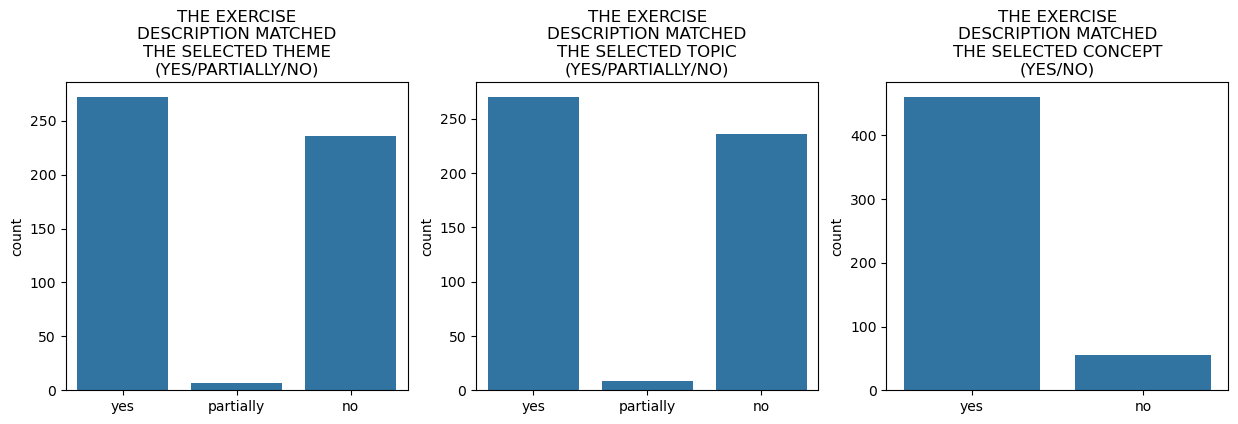

In [6]:
LABELS = [["yes", "partially", "no"], ["yes", "partially", "no"], ["yes", "no"]] # Labels per column
COLS = ['The exercise description matched the selected theme (Yes/Partially/No)',
       'The exercise description matched the selected topic (Yes/Partially/No)',
       'The exercise description matched the selected concept (Yes/No)']

def plot_distributions(df, axes, labels=LABELS, cols=COLS):
    fig = axes[0].figure

    for i, (col, ls) in enumerate(zip(cols, labels)):
        sns.countplot(x=df[col], order=ls, ax=axes[i])
        axes[i].set_title(wrap_text(f"{col.upper()}", 20))
        axes[i].set_xlabel("")

    return fig, axes

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

plot_distributions(concated, ax)

plt.show()

In [7]:
labeled_yes_no = concated.copy()
labeled_yes_no.iloc[:, eval_cols] = labeled_yes_no.iloc[:, eval_cols].map(lambda x: "no" if x == "partially" else x)

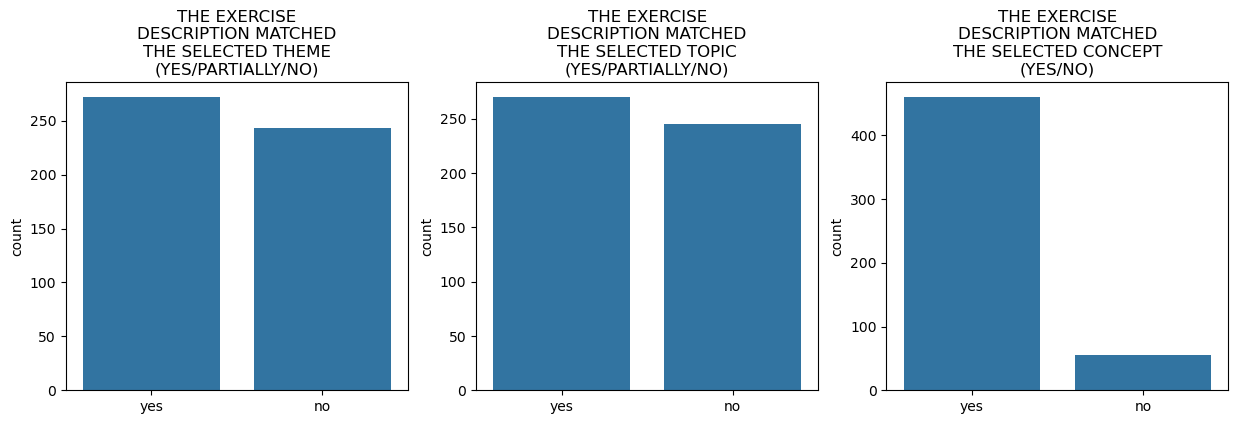

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

plot_distributions(labeled_yes_no, ax, labels=[["yes", "no"]] * 3)

plt.show()